In [23]:
### Packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

### Test GitHub push

# 1st model

## Parameters

In [24]:
### Global variables

# Reflectivity
R0 = 2
c = 0.5

# Definition of V(Q,t)
a0 = -5
tau = 5
a1 = 1
tau1 = 10
a2 = 1
tau2 = 10
b = 0.5

# Equation of motion
d = 0.05 # Damping
Meff = 1 # Effective mass

# Computation parameters
dt = 0.01 # Time quantization
Tstart = -2
Tend = 40 # Total simulation time

In [25]:
def init_params():
    params = {
    "R_0": R0,
    "c_R": c,
    "a_0": a0,
    "tau_0": tau,
    "a_1": a1,
    "tau_1": tau1,
    "a_2": a2,
    "tau_2": tau2,
    "b0": b,
    "damp": d,
    "M": Meff,
    "difft": dt,
    "Ti": Tstart,
    "Tf": Tend
    }
    return params

params = init_params()

## Potential/equation of motion

### Defintion of a(t), potential changes...

In [26]:
### Potential defintion

def a(t):
    a=params["a_0"]
    if t>=0:
        a+=params["a_1"]*np.exp(-t/params["tau_1"])
    if t>=params["tau_0"]:
        a+=params["a_2"]*np.exp(-(t-params["tau_0"])/params["tau_2"])
    return a

print(a(0),a0)

def V(Q,t):
    return a(t)*(Q**2) + b*(Q**4)

def dV(Q,t): # We directly define the potential derivative, avoiding useless computations
    return 2*a(t)*Q + 4*b*(Q**3)

-4.0 -5


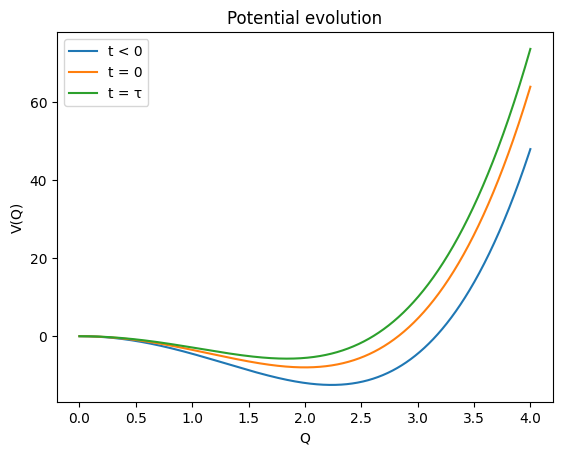

In [27]:
Qex = np.linspace(0,4,1000)

plt.figure()
plt.plot(Qex, V(Qex, -1), label="t < 0")
plt.plot(Qex, V(Qex, 0), label="t = 0")
plt.plot(Qex, V(Qex, params["tau_0"]), label="t = τ")

plt.xlabel("Q")
plt.ylabel("V(Q)")
plt.title("Potential evolution")
plt.legend()

plt.show()

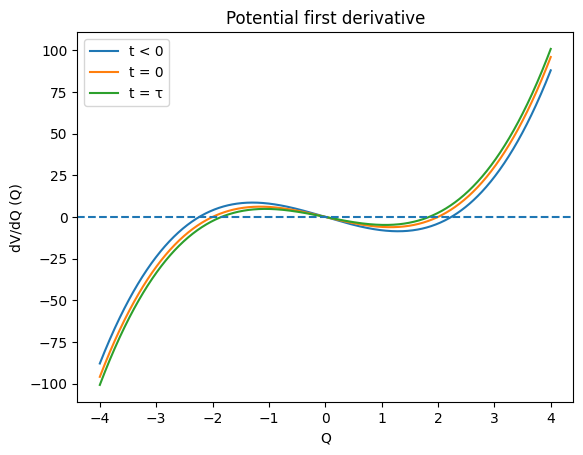

In [28]:
Qex = np.linspace(-4,4,1000)

plt.figure()
plt.plot(Qex, dV(Qex, -1), label="t < 0")
plt.plot(Qex, dV(Qex, 0), label="t = 0")
plt.plot(Qex, dV(Qex, params["tau_0"]), label="t = τ")
plt.axhline(0, linestyle='--')

plt.xlabel("Q")
plt.ylabel("dV/dQ (Q)")
plt.title("Potential first derivative")
plt.legend()

plt.show()

In [29]:
### Computing next value of Q

def update(Q,t): #both Q and t are arrays
    tn = t[-1]+dt
    Qn = (Meff*(2*Q[-1]-Q[-2])-dV(Q[-1],tn)*dt*dt+d*dt*Q[-1])/(Meff+d*dt)
    return Qn,tn


In [30]:
### Whole computation

## Initialization
t = []
tn = Tstart
t.append(tn)
Q0 = [np.sqrt(-a0/(2*b))]
Q = [Q0[0],Q0[0]]

## Main loop
while tn<=Tend:
    Qn,tn = update(Q,t)
    Q.append(Qn)
    t.append(tn)
    Q0.append(np.sqrt(-a(tn)/(2*b)))
Q = Q[1:]
print(len(Q),len(t), len (Q0))


4201 4201 4201


In [31]:
### General defintion 
def compute1():
    ## Initialization
    t = []
    tn = params["Ti"]
    t.append(tn)
    Q0 = [np.sqrt(-params["a_0"]/(2*params["b0"]))]
    Q = [Q0[0],Q0[0]]

    ## Main loop
    while tn<=params["Tf"]:
        Qn,tn = update(Q,t)
        Q.append(Qn)
        t.append(tn)
        Q0.append(np.sqrt(-a(tn)/(2*params["b0"])))
    Q = Q[1:]
    return t,Q,Q0

### Single test

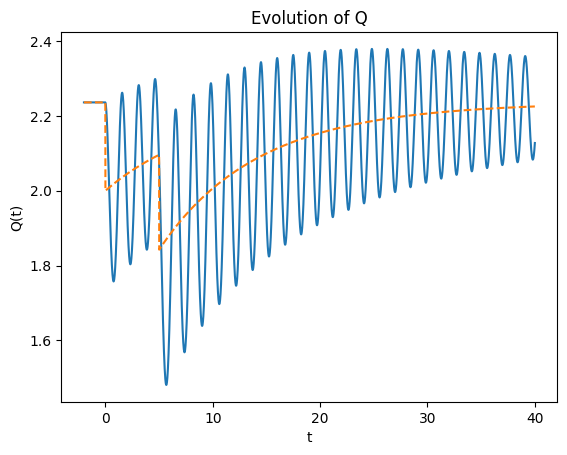

In [32]:
t,Q,Q0 = compute1()

plt.figure()
plt.plot(t, Q)
plt.plot(t, Q0, linestyle='--')

plt.xlabel("t")
plt.ylabel("Q(t)")
plt.title("Evolution of Q")

plt.show()

### Phonon displacement in (Q,V(Q,t)) space

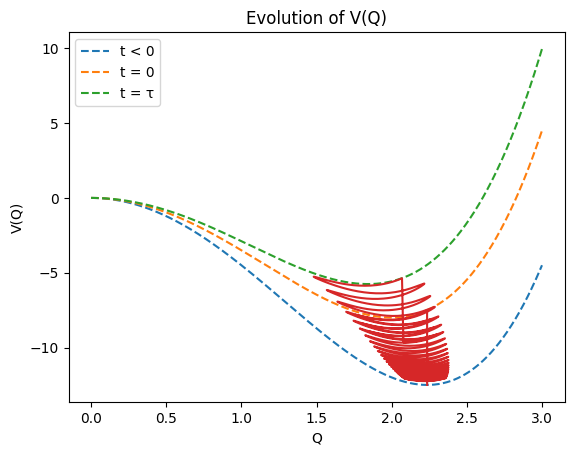

In [33]:
V_Qt = []

for i in range(len(Q)):
    V_Qt.append(V(Q[i],t[i]))

Qex = np.linspace(0,3,1000)
plt.figure()


plt.plot(Qex, V(Qex, -1), label="t < 0", linestyle='--')
plt.plot(Qex, V(Qex, 0), label="t = 0", linestyle='--')
plt.plot(Qex, V(Qex, params["tau_0"]), label="t = τ", linestyle='--')
plt.plot(Q, V_Qt)

plt.xlabel("Q")
plt.ylabel("V(Q)")
plt.title("Evolution of V(Q)")
plt.legend()

plt.show()

## Removing tau1 relaxation

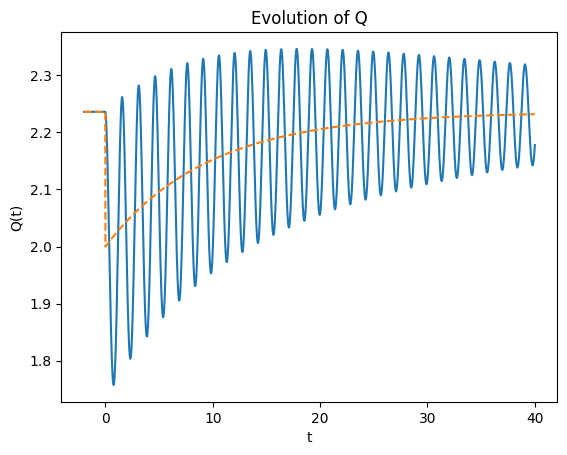

In [34]:
### We first get rid of the second pulse to simplify the fitting
params["a_2"] = 0

t,Q,Q0 = compute1()

plt.figure()
plt.plot(t, Q)
plt.plot(t, Q0, linestyle='--')

plt.xlabel("t")
plt.ylabel("Q(t)")
plt.title("Evolution of Q")

plt.show()

### Reset params
params = init_params

In [66]:
### Trying to fit omega, tau1 and d (damping) from previous results

delta_Q0 = Q0[-1] - np.sqrt((-a0-a1)/(2*b))

def model1(t, f, t1, d):
    t = np.asarray(t)
    
    return np.where(
        t < 0,
        Q0[-1],
        Q0[-1] - delta_Q0 * np.exp(-t/t1) + delta_Q0 * np.cos(f*t) * np.exp(-d*t)
    )
    
def residuals_explicit(f, t1, d, t, data):
    model_vals = model1(t, f, t1, d)
    return model_vals - data

# fitting requires parameter vector
def residuals_wrapper(x, t, data):
    f, t1, d= x
    return residuals_explicit(f, t1, d, t, data)

# initial guess
x0 = [2,50,0.001]

result = least_squares(
    residuals_wrapper,
    x0,
    args=(t, Q),
    bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),
    loss="soft_l1"
)

f_fit, t1_fit, d_fit = result.x

print(f_fit, t1_fit, d_fit)

"""
def model1(t, A, d, f, phi):
    t = np.asarray(t)
    model = Q0[-1] + A * np.exp(-d * t) * np.cos(f * t + phi)
    return np.where(t < 0, Q0[-1], model)

def residuals_explicit(A, d, f, phi, t, data):
    model_vals = model1(t, A, d, f, phi)
    return model_vals - data

def residuals_wrapper(x, t, data):
    A, d, f, phi = x
    return residuals_explicit(A, d, f, phi, t, data)

# initial guess
x0 = [(max(Q) - min(Q))/2, 0.05, 2, 0]

result = least_squares(
    residuals_wrapper,
    x0,
    args=(t, Q),
    bounds=([0, 0, 0, -np.inf], [np.inf, np.inf, np.inf, np.inf]),
    loss="soft_l1"
)

A_fit, d_fit, f_fit, phi_fit = result.x

print(A_fit, d_fit, f_fit, phi_fit)
"""

4.192662775653175 10.779169321919596 0.07420860113307126


'\ndef model1(t, A, d, f, phi):\n    t = np.asarray(t)\n    model = Q0[-1] + A * np.exp(-d * t) * np.cos(f * t + phi)\n    return np.where(t < 0, Q0[-1], model)\n\ndef residuals_explicit(A, d, f, phi, t, data):\n    model_vals = model1(t, A, d, f, phi)\n    return model_vals - data\n\ndef residuals_wrapper(x, t, data):\n    A, d, f, phi = x\n    return residuals_explicit(A, d, f, phi, t, data)\n\n# initial guess\nx0 = [(max(Q) - min(Q))/2, 0.05, 2, 0]\n\nresult = least_squares(\n    residuals_wrapper,\n    x0,\n    args=(t, Q),\n    bounds=([0, 0, 0, -np.inf], [np.inf, np.inf, np.inf, np.inf]),\n    loss="soft_l1"\n)\n\nA_fit, d_fit, f_fit, phi_fit = result.x\n\nprint(A_fit, d_fit, f_fit, phi_fit)\n'

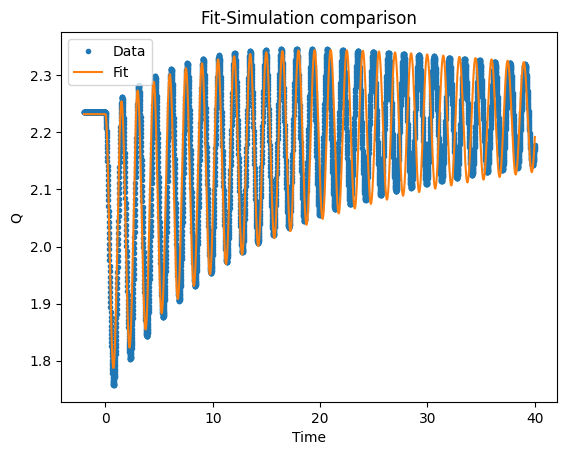

In [67]:
### Comparison between simulation and model

Q_model = model1(t, f_fit, t1_fit, 0.3*d_fit) ### issue with damping fitting...

# Plot
plt.figure()
plt.plot(t, Q, '.', label="Data")
plt.plot(t, Q_model, '-', label="Fit")
plt.xlabel("Time")
plt.ylabel("Q")
plt.legend()
plt.title("Fit-Simulation comparison")
plt.show()

## Simulation

### 2D Map (t and f)

{'R_0': 2, 'c_R': 0.5, 'a_0': -5, 'tau_0': 5, 'a_1': 1, 'tau_1': 30, 'a_2': 1, 'tau_2': 30, 'b0': 0.5, 'damp': 0.05, 'M': 1, 'difft': 0.1, 'Ti': -2, 'Tf': 40}


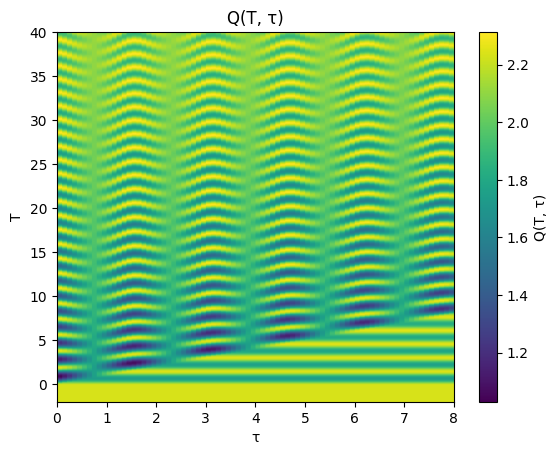

In [17]:
# 2D Map

maxtau = Tend*0.2
taures = 1000

Tres = len(Q)
taurange = np.linspace(0,maxtau,taures)

Q_Ttau = np.zeros((Tres,taures))

params = init_params()
print(params)

for j in range(taures):
    params["tau_0"] = taurange[j]
    t,Q,Q0 = compute1()
    for i in range(len(Q)):
        Q_Ttau[i][j] = Q[i]

params = init_params()

fig, ax = plt.subplots()

im = ax.imshow(
    Q_Ttau,
    origin="lower",
    extent=[taurange[0], taurange[-1], t[0], t[-1]],
    aspect="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Q(T, τ)")

ax.set_xlabel("τ")
ax.set_ylabel("T")
ax.set_title("Q(T, τ)")

plt.show()

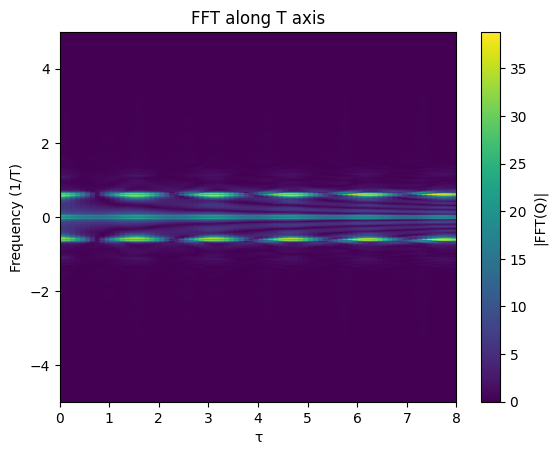

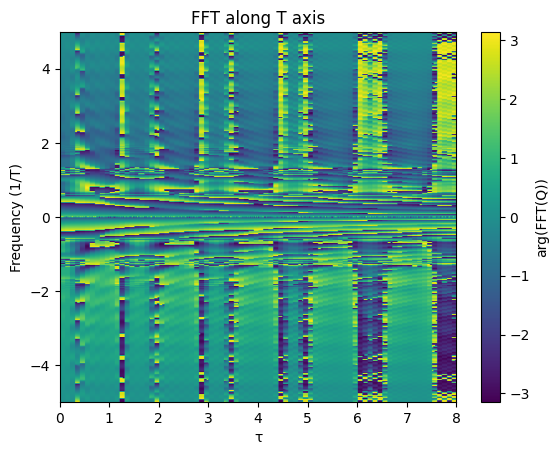

In [18]:
### FFT from previous 2D map (along T)

# Remove DC component (mean along T axis)
Q_centered = Q_Ttau - np.mean(Q_Ttau, axis=0, keepdims=True)

fft_Q = np.fft.fft(Q_centered, axis=0)

# Compute the corresponding frequency axis for T
freq_T = np.fft.fftfreq(len(t), d=dt)

# Shift zero frequency to the center for better visualization
fft_Q_shifted = np.fft.fftshift(fft_Q, axes=0)
freq_T_shifted = np.fft.fftshift(freq_T)



# Plot the magnitude of the FFT
fig, ax = plt.subplots()

im = ax.imshow(
    np.abs(fft_Q_shifted),  # magnitude of the FFT
    origin="lower",
    extent=[taurange[0], taurange[-1], freq_T_shifted[0], freq_T_shifted[-1]],
    aspect="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("|FFT(Q)|")

ax.set_xlabel("τ")
ax.set_ylabel("Frequency (1/T)")
ax.set_title("FFT along T axis")

plt.show()

# Plot the phase of the FFT
fig, ax = plt.subplots()

im = ax.imshow(
    np.angle(fft_Q_shifted),  # phase of the FFT
    origin="lower",
    extent=[taurange[0], taurange[-1], freq_T_shifted[0], freq_T_shifted[-1]],
    aspect="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("arg(FFT(Q))")

ax.set_xlabel("τ")
ax.set_ylabel("Frequency (1/T)")
ax.set_title("FFT along T axis")

plt.show()

### 2 pulse - 1 pulse measurement

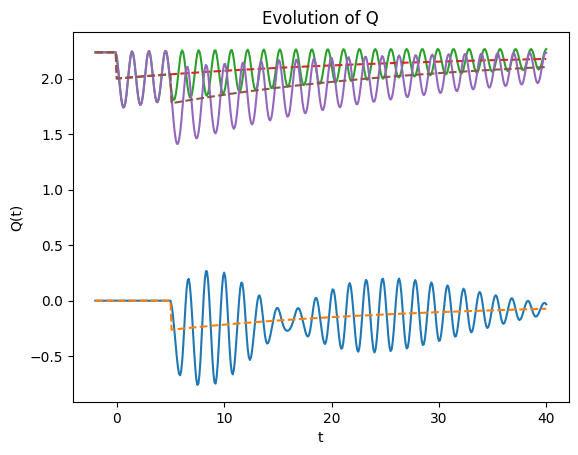

In [19]:
### 2 pulse - 1 pulse

params = init_params()
t2,Q2,Q02 = compute1()
params["a_2"] = 0
t1,Q1,Q01 = compute1()
params = init_params()
t = t2
Q = np.array(Q2) - np.array(Q1)
Q0 = np.array(Q02) - np.array(Q01)

plt.figure()
plt.plot(t, Q)
plt.plot(t, Q0, linestyle='--')
plt.plot(t, Q1)
plt.plot(t, Q01, linestyle='--')
plt.plot(t, Q2)
plt.plot(t, Q02, linestyle='--')

plt.xlabel("t")
plt.ylabel("Q(t)")
plt.title("Evolution of Q")

plt.show()


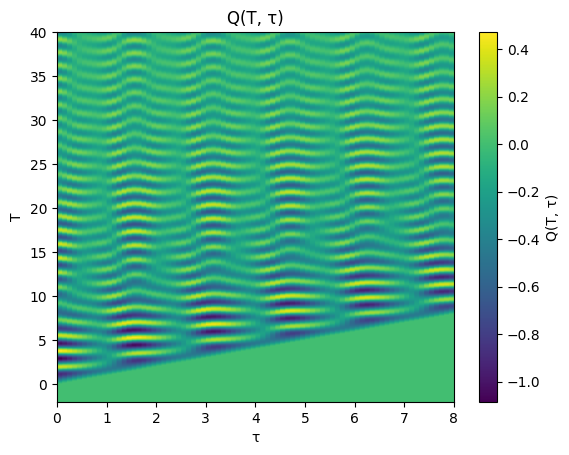

In [26]:
### 2 pulse - 1 pulse : 2D map

maxtau = Tend*0.2
taures = 1000

Tres = len(Q)
taurange = np.linspace(0,maxtau,taures)

Q_Ttau = np.zeros((Tres,taures))

params = init_params()

for j in range(taures):
    params["tau_0"] = taurange[j]
    t2,Q2,Q02 = compute1()
    params["a_2"] = 0
    t1,Q1,Q01 = compute1()
    params = init_params()
    Q = np.array(Q2) - np.array(Q1)
    for i in range(len(Q)):
        Q_Ttau[i][j] = Q[i]


params = init_params()

fig, ax = plt.subplots()

im = ax.imshow(
    Q_Ttau,
    origin="lower",
    extent=[taurange[0], taurange[-1], t[0], t[-1]],
    aspect="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Q(T, τ)")

ax.set_xlabel("τ")
ax.set_ylabel("T")
ax.set_title("Q(T, τ)")

plt.show()

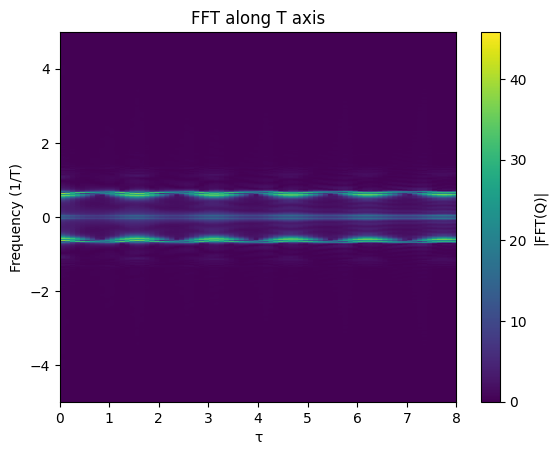

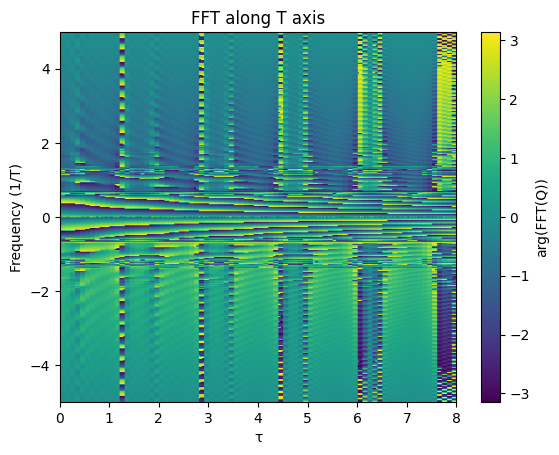

In [27]:
### FFT from previous 2D map (along T)

# Remove DC component (mean along T axis)
Q_centered = Q_Ttau - np.mean(Q_Ttau, axis=0, keepdims=True)

fft_Q = np.fft.fft(Q_centered, axis=0)

# Compute the corresponding frequency axis for T
freq_T = np.fft.fftfreq(len(t), d=dt)

# Shift zero frequency to the center for better visualization
fft_Q_shifted = np.fft.fftshift(fft_Q, axes=0)
freq_T_shifted = np.fft.fftshift(freq_T)



# Plot the magnitude of the FFT
fig, ax = plt.subplots()

im = ax.imshow(
    np.abs(fft_Q_shifted),  # magnitude of the FFT
    origin="lower",
    extent=[taurange[0], taurange[-1], freq_T_shifted[0], freq_T_shifted[-1]],
    aspect="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("|FFT(Q)|")

ax.set_xlabel("τ")
ax.set_ylabel("Frequency (1/T)")
ax.set_title("FFT along T axis")

plt.show()

# Plot the phase of the FFT
fig, ax = plt.subplots()

im = ax.imshow(
    np.angle(fft_Q_shifted),  # phase of the FFT
    origin="lower",
    extent=[taurange[0], taurange[-1], freq_T_shifted[0], freq_T_shifted[-1]],
    aspect="auto"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("arg(FFT(Q))")

ax.set_xlabel("τ")
ax.set_ylabel("Frequency (1/T)")
ax.set_title("FFT along T axis")

plt.show()

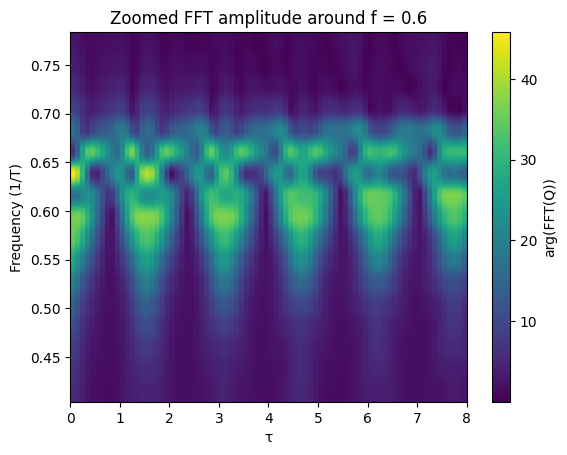

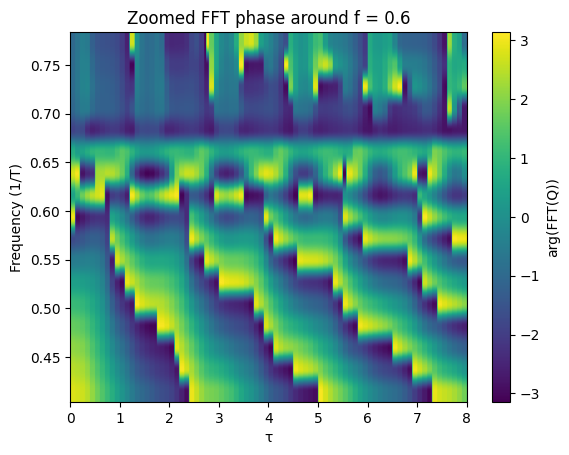

In [28]:
### Zoom around a given frequency
f0 = 0.6
df = 0.2

mask = (freq_T_shifted >= f0 - df) & (freq_T_shifted <= f0 + df)

freq_zoom = freq_T_shifted[mask]
fft_zoom = fft_Q_shifted[mask, :]

amplitude_zoom = np.abs(fft_zoom)
phase_zoom = np.angle(fft_zoom)

phase_zoom = np.where(amplitude_zoom > 1e-6, phase_zoom, np.nan)

###Amplitude zoom
fig, ax = plt.subplots()

im = ax.imshow(
    amplitude_zoom,
    origin="lower",
    extent=[taurange[0], taurange[-1], freq_zoom[0], freq_zoom[-1]],
    aspect="auto",
    #cmap="twilight"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("arg(FFT(Q))")

ax.set_xlabel("τ")
ax.set_ylabel("Frequency (1/T)")
ax.set_title(f"Zoomed FFT amplitude around f = {f0}")

plt.show()

### Phase zoom
fig, ax = plt.subplots()

im = ax.imshow(
    phase_zoom,
    origin="lower",
    extent=[taurange[0], taurange[-1], freq_zoom[0], freq_zoom[-1]],
    aspect="auto",
    #cmap="twilight"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("arg(FFT(Q))")

ax.set_xlabel("τ")
ax.set_ylabel("Frequency (1/T)")
ax.set_title(f"Zoomed FFT phase around f = {f0}")

plt.show()